# **POISSON PROCESS**
## Monte-Carlo Simulation of a Poisson Process

As a next example for the Monte-Carlo simulation of stochastic processes we consider the Poisson Process. It is defined as follows:
- stochastic process is a family of random variables parameterized with a time parameter.

**Definition 62 (Poisson Process):**  
Let $\lambda > 0$. A Poisson process with intensity $\lambda$ is defined by

$$
N(t) = \sum_{i=1}^{\infty} \mathbf{1}_{T_i \leq t}
$$

where $T_i = T_{i-1} + \tau_i$ are i.i.d. random variables with exponential distribution with intensity $\lambda$ and $T_0 := 0$.
<p align="center">
<img src="image-32.png" alt="image-33" style="zoom:50%;" />
</p>

If $\tau$ models a time, we see from

$$
P(\tau \leq t) = 1 - \exp(-\lambda t)
$$

or from the inversion of the distribution function

$$
\tau = -\frac{1}{\lambda} \log(1 - u)
$$

that the parameter $\lambda$ has the unit $1/\text{time}$, i.e., it is a frequency, and $1/\lambda$ has the unit time.

Indeed, from the density of $\tau$ being

$$
\varphi(t) = F'(t) = \lambda \exp(-\lambda t)
$$

we have

$$
\mathbb{E}[\tau] = \int_0^{\infty} t \varphi(t) \, dt = \frac{1}{\lambda},
$$

>i.e., $1/\lambda$ is the expected time of the event and $\lambda$ then is the frequency of the events, given that we restart an (independent) experiment after the event has occurred.

$$P(N(t) = k) = ( (λt)^k / k! ) e^{(−λt)}$$

---
There is also an inhomogeneous variant, where the intensity is time-dependent:

**Definition 63 (Inhomogeneous Poisson Process):**  
Let $\lambda(t): [0, \infty) \rightarrow [0, \infty)$ and define

$$
\Lambda(t) := \int_0^t \lambda(s) \, ds.
$$

Let $Y(t)$ be a Poisson process with intensity $1$. Then the process

$$
X(t) = Y(\Lambda(t))
$$

is called an **inhomogeneous Poisson process** with intensity $\lambda(t)$.

---

> *Handwritten annotations:*
- Time change: $t \rightarrow \Lambda(t)$  
- $\frac{\partial \lambda}{\partial t} = \lambda(t)$  ~ velocity

---
For a given time-horizon $T$ we sample the jump-times $T_i$ required to calculate $N$ on $[0, T]$.  
That is:

For a given $\omega_j$ we need to draw $n_j$ random numbers $Z_i(\omega_j)$ from an exponential distribution,  
where $n_j$ is such that

$$
T_k(\omega_j) \leq T < T_{k+1}(\omega_j) \quad \text{for } k = n_j.
$$

The amount of random numbers needed to sample one $\omega_j$ depends on that $\omega_j$.


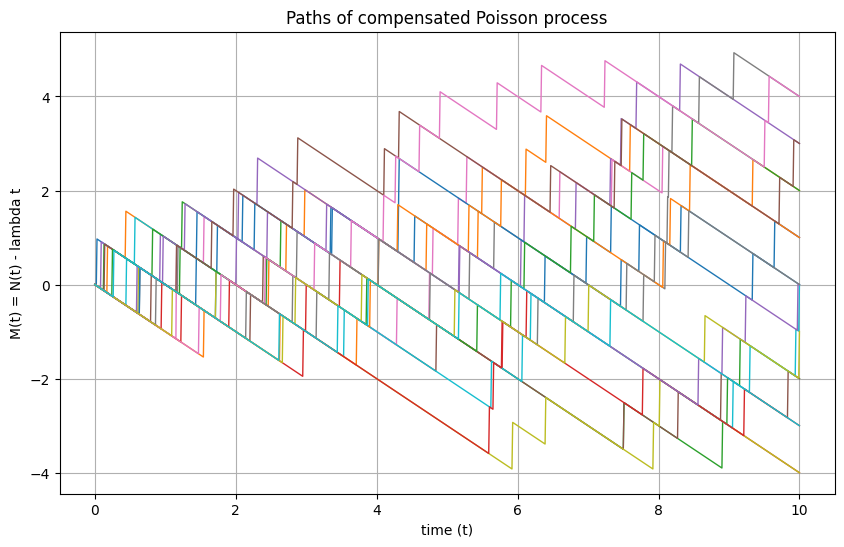

In [1]:
import PoissonProcessExperiment as ppe
a = ppe.PoissonProcessExperiment()
a.plotPoissonPaths()

# Remark 64 (Dimension of the Monte-Carlo Integral)

Assume a financial product depends on the jump times that occur before a maturity $T$.  
For the valuation we are interested in the calculation of

$$
V(t) = \mathbb{E}^{\mathbb{Q}^N}\big(f(\{T_i \leq T\}) \,\big|\, \mathcal{F}_t \big),
$$

<!-- Nota manuscrita: "Numbers of jump times depend on ω" -->

We see that the function $f$ depends on a variable number of stochastic times.  
**The number of stochastic times (jumps) that occur on a given path $\omega$ depends on the path.**  

➡️ *But then, what is the dimension of the Monte-Carlo integral?*

On the other hand, we see from the implementation that we just need to generate a single (one-dimensional) sequence of exponential random numbers.  
When we reached the maturity the sequence will continue to sample the next path.  
This is similar to the method generating a random vector from a one-dimensional sequence, except, that our vectors now have variable length.

---

📌 *This also illustrates how the Monte-Carlo method scales linear in the dimension.*


# `Lemma 65 (Poisson Process)`

We note an important property of a Poisson process:

**Lemma 65 (Poisson Process):**  
Let $N$ be a Poisson process with intensity $\lambda$. Then  

$$
M(t) := N(t) - \lambda t
$$

is a martingale.  

---

### Sloppy Argument

$$
\sum_{i=0}^{N-1} \big(T_{i+1} - T_i\big) = t
$$

where $T_{i+1}-T_i \sim \text{Exp}(\lambda)$.  

Since  

$$
\mathbb{E}[T_{i+1}-T_i] = \tfrac{1}{\lambda},
$$

we have  

$$
\sum_{i=0}^{N-1} \tfrac{1}{\lambda} = t.
$$

Thus approximately  

$$
N \cdot \tfrac{1}{\lambda} = t \quad \Longrightarrow \quad N(t) \approx \lambda t.
$$

---

### Connection to Martingales

The Poisson process grows on average at rate $\lambda$.  
If we subtract this deterministic drift, we obtain  

$$
M(t) = N(t) - \lambda t,
$$

which has **zero conditional expectation increment**, i.e.

$$
\mathbb{E}[M(t+s) - M(t) \mid \mathcal{F}_t] = 0.
$$

Hence $M(t)$ is a **martingale**.


# Notation Summary — Poisson Process

| Symbol                    | Meaning                                                                 |
|----------------------------|-------------------------------------------------------------------------|
| $t \geq 0$                 | Continuous time.                                                        |
| $N(t)$                     | Poisson process at time $t$, i.e. the number of jumps up to time $t$.   |
| $\lambda > 0$              | Intensity (average rate of jumps per unit of time).                     |
| $T_i$                      | Time of the $i$-th jump.                                                |
| $T_{i+1} - T_i$            | Waiting time between successive jumps (iid $\sim \text{Exp}(\lambda)$). |
| $M(t) = N(t) - \lambda t$  | Compensated Poisson process (martingale associated with $N(t)$).        |
| $\mathcal{F}_t$            | Natural filtration of the process (information up to time $t$).         |
| $\mathbb{E}[\cdot]$        | Expectation.                                                            |


# Low Discrepancy Sequences for Monte-Carlo Simulation

Recall that for low discrepancy sequences we are required to use an  
**n-dimensional sequence** when approximating an **n-dimensional integral**.  

For the time-discrete Itô-process the dimension scales with the number of time-steps.  
For the Poisson process, the dimension is not even determined.  


In [27]:
import math as m
a = m.exp(-0.5*5)
b = 1 - a
b

0.9179150013761012

In [6]:
a = 5*0.2
a

1.0

$$P(N(t) = k) = ( (λt)^k / k! ) e^{(−λt)}$$

# Poisson Process – Probability Formulas

| Concept | Formula (Sumatoria) | Meaning |
|---------|----------------------|---------|
| **PMF (exact k events)** | $ P(N(t) = k) = e^{-\lambda t} \dfrac{(\lambda t)^k}{k!} $ | Probability of exactly $k$ events in $[0,t]$. |
| **CDF (≤ k)** | $ P(N(t) \le k) = \sum_{j=0}^{k} e^{-\lambda t} \dfrac{(\lambda t)^j}{j!} $ | Probability of at most $k$ events. |
| **CDF (< k)** | $ P(N(t) < k) = \sum_{j=0}^{k-1} e^{-\lambda t} \dfrac{(\lambda t)^j}{j!} $ | Probability of fewer than $k$ events. |
| **Tail (≥ k)** | $ P(N(t) \ge k) = 1 - \sum_{j=0}^{k-1} e^{-\lambda t} \dfrac{(\lambda t)^j}{j!} $ | Probability of at least $k$ events. |
| **Tail (> k)** | $ P(N(t) > k) = 1 - \sum_{j=0}^{k} e^{-\lambda t} \dfrac{(\lambda t)^j}{j!} $ | Probability of more than $k$ events. |
| **No event** | $ P(N(t) = 0) = e^{-\lambda t} $ | Probability of zero events in $[0,t]$. |
| **At least one event** | $ P(N(t) \ge 1) = 1 - e^{-\lambda t} $ | Complement of no event. |


In [ ]:
#Probabilida de que ocurra al menos un evento antes de s

In [ ]:
import math as m

def ProbPoiss(lambda_, kvalue, t, mode="exact"):
    """
    Probabilidades en un proceso de Poisson.
    
    lambda_: tasa de ocurrencia por unidad de tiempo
    kvalue : número de eventos (entero)
    t      : horizonte temporal
    mode   : "exact", "at_most", "at_least", "range"
    """
    if mode == "exact":
        return ((lambda_*t)**kvalue)/m.factorial(kvalue)*m.exp(-lambda_*t)
    
    elif mode == "at_most":   # P(N(t) <= k)
        return sum(((lambda_*t)**k)/m.factorial(k)*m.exp(-lambda_*t) for k in range(kvalue+1))
    
    elif mode == "at_least":  # P(N(t) >= k)
        return 1 - sum(((lambda_*t)**j)/m.factorial(j)*m.exp(-lambda_*t) for j in range(kvalue))
    
    elif mode == "range":     # P(a <= N(t) <= b)
        a, b = kvalue
        return sum(((lambda_*t)**j)/m.factorial(j)*m.exp(-lambda_*t) for j in range(a, b+1))
    
    else:
        raise ValueError("Mode not recognized")


In [37]:
a = ProbPoiss(3, 2, 1)
a

0.22404180765538775

In [44]:
a = 1 - ProbPoiss(3, 2, 1)
a

0.7759581923446123